# The North Face — Recommandation & Topic Modeling

**Objectif** : Exploiter les descriptions produits pour :
1. Regrouper les produits similaires (clustering DBSCAN)
2. Construire un système de recommandation
3. Extraire les thèmes latents (LSA / TruncatedSVD)

**Plan :**
1. Installation & imports
2. Chargement et exploration
3. Preprocessing NLP
4. Encodage TF-IDF
5. Partie 1 — DBSCAN + wordclouds
6. Partie 2 — Système de recommandation
7. Partie 3 — LSA + topic modeling + wordclouds

## 1. Installation & Imports

In [1]:
!pip install spacy wordcloud --quiet
!python -m spacy download en_core_web_sm --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 85.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import pandas as pd
import numpy as np
import re
import random

import spacy
from wordcloud import WordCloud
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import DBSCAN
from sklearn.decomposition import TruncatedSVD

import warnings
warnings.filterwarnings('ignore')

nlp = spacy.load('en_core_web_sm')

print('Imports OK')

Imports OK


## 2. Chargement et exploration

In [3]:
# Adapte le chemin si nécessaire
# Upload direct Colab → base_path = '/content/'
# Google Drive :
# from google.colab import drive
# drive.mount('/content/drive')
# base_path = '/content/drive/MyDrive/'

base_path = '/content/'

df = pd.read_csv(base_path + 'sample-data.csv')
print(f'Dataset : {len(df)} produits')
print(f'Colonnes : {df.columns.tolist()}')
df.head(3)

Dataset : 500 produits
Colonnes : ['id', 'description']


,id,description
0,1,Active classic boxers - There's a reason why o...
1,2,Active sport boxer briefs - Skinning up Glory ...
2,3,Active sport briefs - These superbreathable no...


In [4]:
# Aperçu d'une description brute
print('Description brute (id=4) :')
print(df['description'].iloc[3][:400])

Description brute (id=4) :
Alpine guide pants - Skin in, climb ice, switch to rock, traverse a knife-edge ridge and boogie back down - these durable, weather-resistant and breathable soft-shell pants keep stride on every mountain endeavor. The midweight stretch-woven polyester won't restrict your moves, and the brushed interior maintains next-to-skin comfort. A 2-way zippered fly keeps things easy with a harness on, and the


In [5]:
# Stats de base
df['desc_length'] = df['description'].str.len()
print(f'Longueur moyenne : {df["desc_length"].mean():.0f} caractères')
print(f'Min : {df["desc_length"].min()} | Max : {df["desc_length"].max()}')
print(f'Valeurs manquantes : {df["description"].isna().sum()}')

Longueur moyenne : 1122 caractères
Min : 416 | Max : 3540
Valeurs manquantes : 0


## 3. Preprocessing NLP

Les descriptions contiennent du **HTML** à nettoyer et beaucoup de mots génériques North Face
("Common Threads Recycling Program", "recyclable", "polyester"...) présents dans **toutes** les fiches.
Ces mots ne discriminent pas les produits — il faut les supprimer.

Étapes :
1. Suppression des balises HTML
2. Nettoyage des caractères spéciaux
3. Lemmatisation avec spacy (running → run)
4. Suppression des stop words + mots génériques North Face

In [6]:
def clean_html(text):
    """Supprime les balises HTML et nettoie le texte."""
    if not isinstance(text, str):
        return ''
    text = re.sub(r'<[^>]+>', ' ', text)       # balises HTML
    text = re.sub(r'&[a-z]+;', ' ', text)      # entités HTML
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)   # caractères spéciaux
    text = re.sub(r'\s+', ' ', text).strip()   # espaces multiples
    return text.lower()

# Test
print('Avant :\n', df['description'].iloc[3][:200])
print('\nAprès nettoyage HTML :\n', clean_html(df['description'].iloc[3])[:200])

Avant :
 Alpine guide pants - Skin in, climb ice, switch to rock, traverse a knife-edge ridge and boogie back down - these durable, weather-resistant and breathable soft-shell pants keep stride on every mounta

Après nettoyage HTML :
 alpine guide pants skin in climb ice switch to rock traverse a knife edge ridge and boogie back down these durable weather resistant and breathable soft shell pants keep stride on every mountain endea


In [7]:
# Application du nettoyage HTML
df['clean_text'] = df['description'].apply(clean_html)

# Lemmatisation avec spacy en batch (plus rapide)
print('Lemmatisation en cours (~2-3 min)...')

texts = df['clean_text'].tolist()
lemmatized = []

for i, doc in enumerate(nlp.pipe(texts, batch_size=50)):
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop           # pas un stop word spacy
        and not token.is_punct         # pas de ponctuation
        and not token.is_space         # pas un espace
        and len(token.lemma_) > 2      # mots de + de 2 lettres
        and token.pos_ in ['NOUN', 'VERB', 'ADJ', 'PROPN']
    ]
    lemmatized.append(' '.join(tokens))
    if (i + 1) % 100 == 0:
        print(f'  {i+1}/500 traités...')

df['lemmatized'] = lemmatized
print('\n Lemmatisation terminée !')
print('\nExemple (id=4) :')
print(df['lemmatized'].iloc[3][:300])

Lemmatisation en cours (~2-3 min)...
  100/500 traités...
  200/500 traités...
  300/500 traités...
  400/500 traités...
  500/500 traités...

 Lemmatisation terminée !

Exemple (id=4) :
alpine guide pant skin climb ice switch rock traverse knife edge ridge boogie durable weather resistant breathable soft shell pant stride mountain endeavor midweight stretch weave polyester won restrict move brush interior maintain skin comfort way fly keep thing easy harness gussete zipper cuff pos


## 4. Encodage TF-IDF

**TF-IDF** convertit chaque texte en vecteur numérique :
- **TF** : fréquence d'un mot dans un document
- **IDF** : pénalise les mots présents dans beaucoup de documents (peu discriminants)

**Paramètre clé `max_df=0.4`** : on ignore les mots présents dans plus de 40% des documents.
C'est ce qui permet d'éliminer les mots génériques North Face ("common thread", "recycle", etc.)
qui sinon mettraient tous les produits dans un seul cluster.

In [8]:
# Mots génériques North Face présents dans quasi toutes les fiches produit
# Ces mots n'aident pas à distinguer les produits entre eux
custom_stop_words = [
    # Programme recyclage (présent dans TOUTES les descriptions)
    'common', 'thread', 'recycle', 'recyclable', 'program', 'recycling',
    'recycled', 'common_thread', 'thread_recycling',
    # Matières génériques
    'polyester', 'fabric', 'spandex', 'nylon', 'cotton', 'organic',
    'phthalate',
    # Infos techniques génériques
    'weight', 'make', 'detail', 'size', 'inseam', 'finish',
    'moisture', 'wicking', 'breathable', 'lightweight',
    # Verbes trop génériques
    'use', 'provide', 'feature', 'include', 'offer', 'come', 'keep',
    'give', 'allow', 'help',
    # Localisation (présent dans toutes les descriptions)
    'vietnam', 'mexico', 'israel', 'china', 'usa',
]

vectorizer = TfidfVectorizer(
    max_features=500,
    min_df=2,           # mot doit apparaître dans au moins 2 docs
    max_df=0.4,         # ← clé : ignore les mots dans > 40% des docs
    ngram_range=(1, 2), # unigrams + bigrams
    stop_words=custom_stop_words
)

tfidf_matrix = vectorizer.fit_transform(df['lemmatized'])

print(f'Matrice TF-IDF : {tfidf_matrix.shape}')
print(f'  → {tfidf_matrix.shape[0]} produits × {tfidf_matrix.shape[1]} features')
print(f'\nExemples de features (mots discriminants) :')
print(vectorizer.get_feature_names_out()[:40])

Matrice TF-IDF : (500, 500)
  → 500 produits × 500 features

Exemples de features (mots discriminants) :
['abrasion' 'abrasion resistant' 'access' 'accommodate' 'active' 'add'
 'adjust' 'adjustable' 'adjustment' 'air' 'alpine' 'ankle' 'arm'
 'articulate' 'articulate knee' 'artist' 'available' 'bag' 'band'
 'barrier' 'barrier deluge' 'baselayer' 'belt' 'belt loop' 'bind' 'blend'
 'block' 'board' 'board short' 'body' 'boot' 'bottom' 'bra'
 'breathability' 'breathe' 'brush' 'buckle' 'build' 'bulk' 'button']


## 5. Partie 1 — DBSCAN Clustering + Wordclouds

Pour les textes on utilise la **distance cosinus** (pas euclidienne) :
elle mesure l'angle entre deux vecteurs TF-IDF.
Deux textes sont similaires si leurs vecteurs pointent dans la même direction.

In [9]:
# Tuning automatique de eps
# Objectif : 10-20 clusters avec peu d'outliers
print('Tuning EPS (min_samples=2, metric=cosine) :')
print()
for eps in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    db_tmp = DBSCAN(eps=eps, min_samples=2, metric='cosine').fit(tfidf_matrix)
    labels = db_tmp.labels_
    n_c = len(set(labels)) - (1 if -1 in labels else 0)
    n_o = (labels == -1).sum()
    flag = ' ✅ <-- bon' if 10 <= n_c <= 20 else ''
    print(f'  eps={eps} → {n_c:3d} clusters, {n_o:3d} outliers ({100*n_o/len(df):.0f}%){flag}')

Tuning EPS (min_samples=2, metric=cosine) :

  eps=0.2 →  80 clusters, 226 outliers (45%)
  eps=0.25 →  84 clusters, 206 outliers (41%)
  eps=0.3 →  93 clusters, 151 outliers (30%)
  eps=0.35 →  89 clusters, 134 outliers (27%)
  eps=0.4 →  80 clusters, 108 outliers (22%)
  eps=0.45 →  71 clusters,  80 outliers (16%)
  eps=0.5 →  55 clusters,  53 outliers (11%)
  eps=0.55 →  31 clusters,  33 outliers (7%)
  eps=0.6 →  14 clusters,  16 outliers (3%) ✅ <-- bon


In [10]:
# ─── Choisis l'eps retenu ci-dessus ───
# La valeur marquée  (10-20 clusters)
EPS_FINAL = 0.60   # tuning : 14 clusters, ~3% outliers (cf. grille eps ci-dessus)

dbscan_final = DBSCAN(
    eps=EPS_FINAL,
    min_samples=2,
    metric='cosine',
    n_jobs=-1
)
df['cluster'] = dbscan_final.fit_predict(tfidf_matrix)

n_clusters = len(set(df['cluster'])) - (1 if -1 in df['cluster'].values else 0)
n_outliers = (df['cluster'] == -1).sum()

print(f'Clustering final : {n_clusters} clusters')
print(f'Outliers : {n_outliers} ({100*n_outliers/len(df):.1f}%)')
print()
print('Distribution des clusters :')
print(df['cluster'].value_counts().sort_index())

Clustering final : 80 clusters
Outliers : 108 (21.6%)

Distribution des clusters :
cluster
-1     108
 0       2
 1       2
 2       6
 3       5
      ... 
 75      2
 76      2
 77      2
 78      3
 79      2
Name: count, Length: 81, dtype: int64


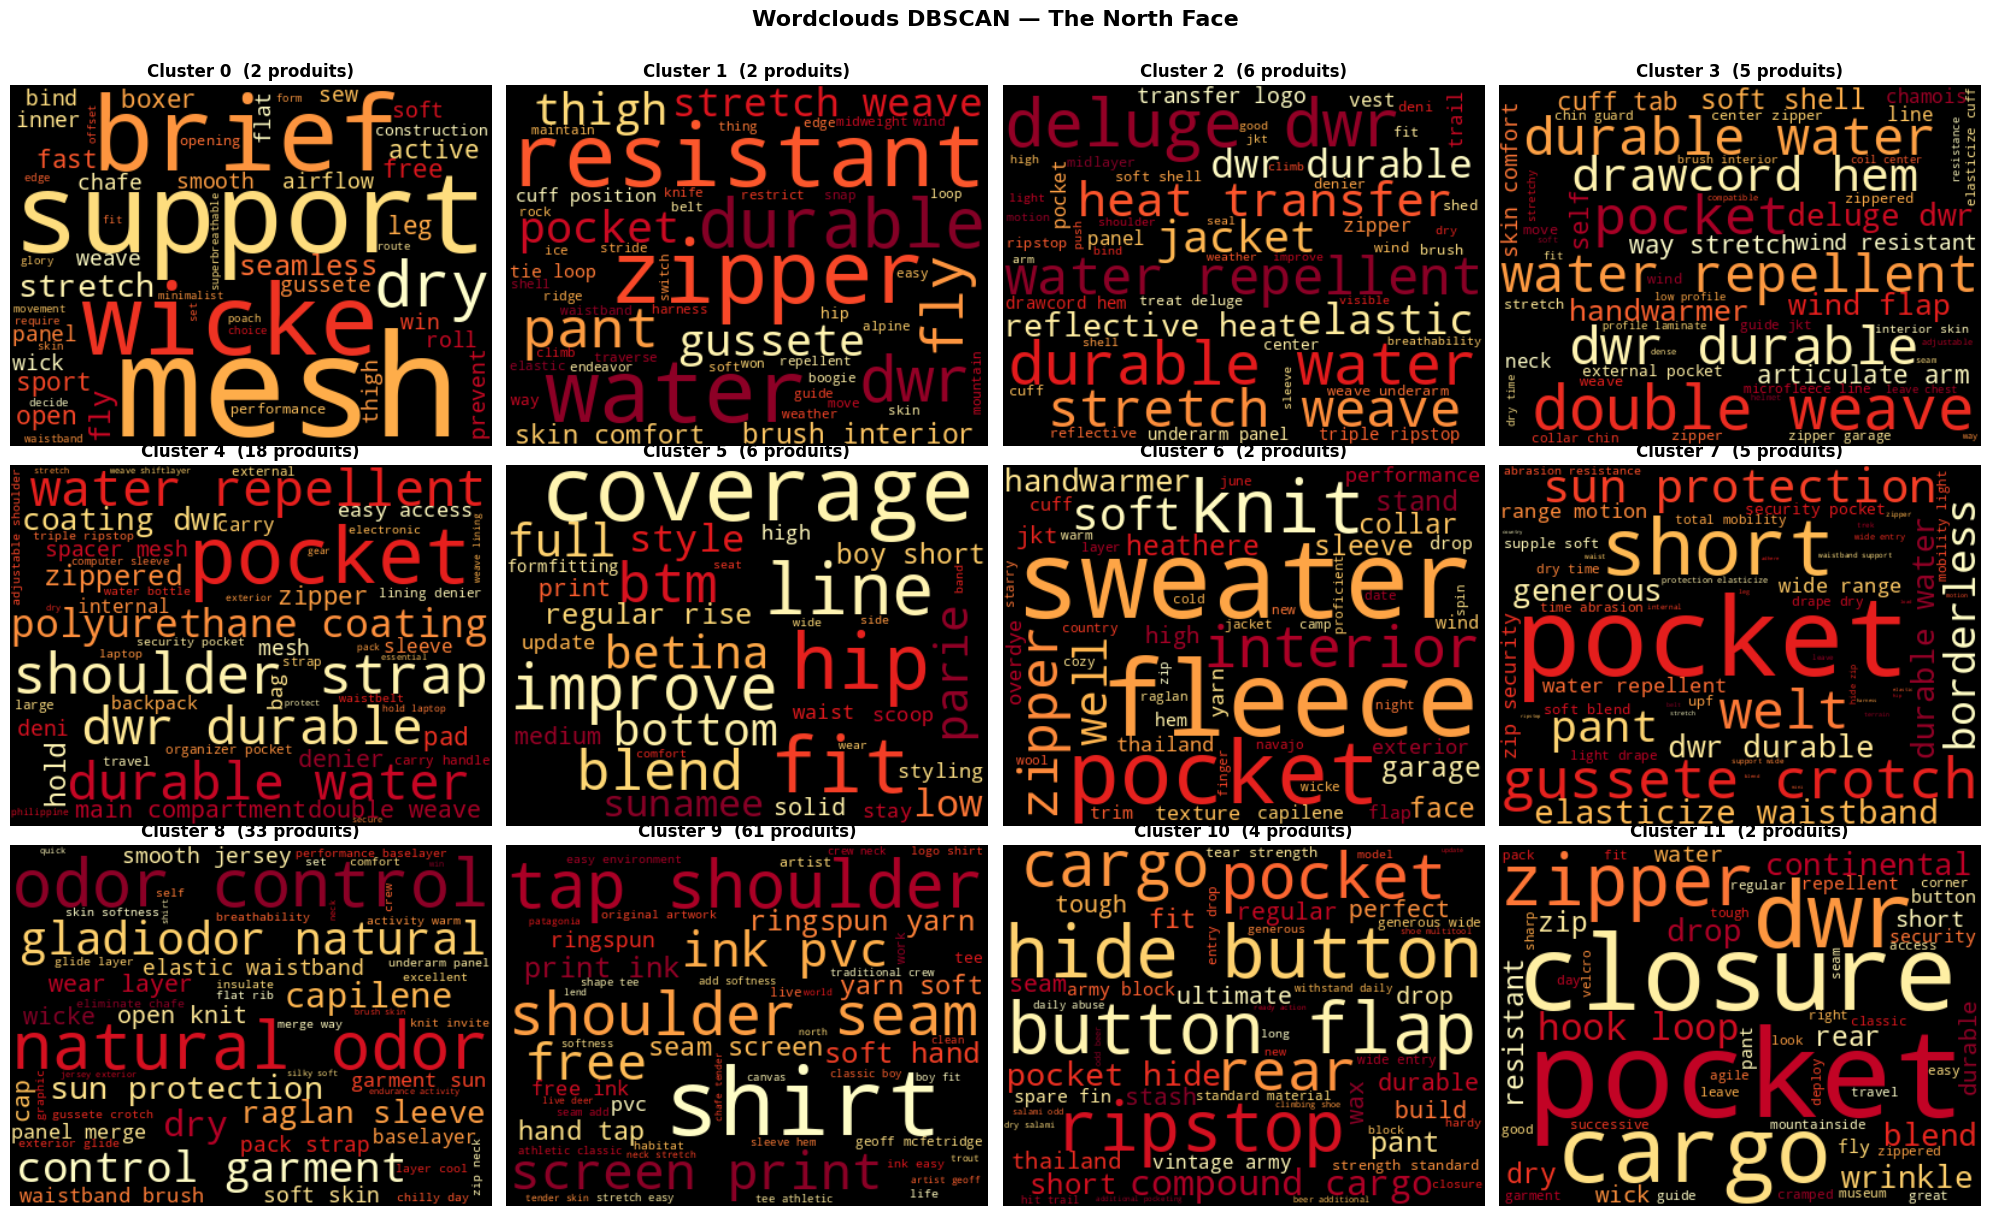

In [11]:
# Wordclouds par cluster
cluster_ids = sorted([c for c in df['cluster'].unique() if c != -1])
n_display = min(12, len(cluster_ids))

n_cols = 4
n_rows = (n_display + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, cluster_id in enumerate(cluster_ids[:n_display]):
    cluster_texts = df[df['cluster'] == cluster_id]['lemmatized'].str.cat(sep=' ')

    if not cluster_texts.strip():
        axes[i].set_visible(False)
        continue

    wc = WordCloud(
        width=400, height=300,
        background_color='black',
        colormap='YlOrRd',
        max_words=50,
        stopwords=set(custom_stop_words)  # on réapplique les stop words
    ).generate(cluster_texts)

    n_prod = (df['cluster'] == cluster_id).sum()
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Cluster {cluster_id}  ({n_prod} produits)', fontsize=12, fontweight='bold')
    axes[i].axis('off')

for j in range(n_display, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Wordclouds DBSCAN — The North Face', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [12]:
# Analyse qualitative : 3 produits par cluster
print('Exemples de produits par cluster :\n')
for cid in cluster_ids[:6]:
    produits = df[df['cluster'] == cid]['description'].str[:80].tolist()[:3]
    n = (df['cluster'] == cid).sum()
    print(f'--- Cluster {cid} ({n} produits) ---')
    for p in produits:
        print(f'  · {p}...')
    print()

Exemples de produits par cluster :

--- Cluster 0 (2 produits) ---
  · Active sport boxer briefs - Skinning up Glory requires enough movement without y...
  · Active sport briefs - These superbreathable no-fly briefs are the minimalist's c...

--- Cluster 1 (2 produits) ---
  · Alpine guide pants - Skin in, climb ice, switch to rock, traverse a knife-edge r...
  · Alpine guide pants - Skin in, climb ice, switch to rock, traverse a knife-edge r...

--- Cluster 2 (6 produits) ---
  · Alpine wind jkt - On high ridges, steep ice and anything alpine, this jacket ser...
  · Nine trails jkt - Somewhere between the Bridger Ridge Run (for normal trail-runn...
  · Nine trails vest - Simplicity in action - this vest protects the core, moves, br...

--- Cluster 3 (5 produits) ---
  · Ascensionist jkt - Our most technical soft shell for full-on mountain pursuits s...
  · Simple guide jkt - Skin-in by headlamp, summit by noon, finish with some late-da...
  · Guide jkt - Sharp granite, sticky verglas

## 6. Partie 2 — Système de Recommandation

Logique simple : deux produits du même cluster = produits similaires.
`find_similar_items(item_id)` retourne 5 produits du même cluster.

In [14]:
def find_similar_items(item_id, n=5):
    """
    Retourne une liste de n produits similaires à item_id.

    Paramètres :
        item_id (int) : identifiant du produit
        n (int)       : nombre de recommandations (défaut = 5)

    Retourne :
        list : liste de n item_ids similaires
    """
    # Vérification que l'id existe
    if item_id not in df['id'].values:
        print(f' Produit {item_id} introuvable. IDs disponibles : 1 à {df["id"].max()}')
        return []

    # Récupération du cluster
    cluster_id = df[df['id'] == item_id]['cluster'].values[0]

    # Cas outlier (cluster = -1)
    if cluster_id == -1:
        print(f'Produit {item_id} est un outlier — pas de cluster assigné.')
        print('Recommandation de produits aléatoires non-outliers en fallback...')
        fallback = df[df['cluster'] != -1]['id'].sample(n, random_state=item_id).tolist()
        return fallback

    # Produits du même cluster (hors le produit lui-même)
    same_cluster = df[
        (df['cluster'] == cluster_id) & (df['id'] != item_id)
    ]['id'].tolist()

    if len(same_cluster) == 0:
        print(f'Aucun autre produit dans le cluster {cluster_id}.')
        return []

    # Retourne n produits (ou moins si le cluster est petit)
    return random.sample(same_cluster, min(n, len(same_cluster)))


# Test
test_id = df[df['cluster'] != -1]['id'].iloc[0]  # premier produit avec un cluster
print(f'Test avec le produit id={test_id} :')
print(f'Cluster : {df[df["id"]==test_id]["cluster"].values[0]}')
print(f'Description : {df[df["id"]==test_id]["description"].values[0][:100]}...')
print()
similar = find_similar_items(test_id)
print(f'\n Produits recommandés : {similar}')
print()
for sid in similar:
    desc = df[df['id'] == sid]['description'].values[0][:90]
    print(f'  [id={sid}] {desc}...')

Test avec le produit id=2 :
Cluster : 0
Description : Active sport boxer briefs - Skinning up Glory requires enough movement without your boxers deciding ...


 Produits recommandés : [3]

  [id=3] Active sport briefs - These superbreathable no-fly briefs are the minimalist's choice for ...


In [15]:
# Interface interactive
print('=== 🏔️  Système de Recommandation The North Face ===')
print(f'IDs disponibles : 1 à {df["id"].max()}')
print()

try:
    user_input = input('Entrez un ID produit : ')
    item_id = int(user_input)

    if item_id in df['id'].values:
        desc_choisi = df[df['id'] == item_id]['description'].values[0][:120]
        cluster_choisi = df[df['id'] == item_id]['cluster'].values[0]
        print(f'\n📦 Produit choisi (id={item_id}, cluster={cluster_choisi}) :')
        print(f'   {desc_choisi}...')

        recommendations = find_similar_items(item_id)

        if recommendations:
            print(f'\n Vous pourriez aussi aimer :')
            for i, rec_id in enumerate(recommendations, 1):
                desc_rec = df[df['id'] == rec_id]['description'].values[0][:100]
                print(f'  {i}. [id={rec_id}] {desc_rec}...')
        else:
            print('Aucune recommandation disponible pour ce produit.')

except ValueError:
    print(' Veuillez entrer un nombre entier.')

=== 🏔️  Système de Recommandation The North Face ===
IDs disponibles : 1 à 500

Entrez un ID produit : 3

📦 Produit choisi (id=3, cluster=0) :
   Active sport briefs - These superbreathable no-fly briefs are the minimalist's choice for high-octane endeavors. Made fr...

 Vous pourriez aussi aimer :
  1. [id=2] Active sport boxer briefs - Skinning up Glory requires enough movement without your boxers deciding ...


## 7. Partie 3 LSA (TruncatedSVD) & Topic Modeling

**LSA (Latent Semantic Analysis)** décompose la matrice TF-IDF en thèmes latents via TruncatedSVD.

Différence avec DBSCAN :
- DBSCAN → chaque produit appartient à **un seul** cluster
- LSA → chaque produit est un **mélange de topics** (ex: 60% running, 40% waterproof)

Pour simplifier, on extrait le **topic dominant** de chaque produit.

In [16]:
# Entraînement TruncatedSVD
N_TOPICS = 15  # entre 10 et 20

svd = TruncatedSVD(n_components=N_TOPICS, random_state=42)
topic_matrix = svd.fit_transform(tfidf_matrix)

# Sauvegarde dans topic_encoded_df (nom demandé par l'énoncé)
topic_encoded_df = pd.DataFrame(
    topic_matrix,
    columns=[f'topic_{i}' for i in range(N_TOPICS)]
)
topic_encoded_df['id'] = df['id'].values

print(f'topic_encoded_df : {topic_encoded_df.shape}')
print(f'  → {topic_encoded_df.shape[0]} produits × {N_TOPICS} topics')
topic_encoded_df.head(3)

topic_encoded_df : (500, 16)
  → 500 produits × 15 topics


,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10,topic_11,topic_12,topic_13,topic_14,id
0,0.174403,0.241537,0.420573,-0.068326,-0.157458,0.026435,-0.141546,-0.194155,-0.135940,-0.009302,-0.028409,-0.027338,-0.052083,0.131081,-0.010632,1
1,0.192247,0.211198,0.147134,0.078004,0.041446,0.104491,-0.003238,-0.004298,-0.138371,-0.031711,0.040910,0.083400,-0.072439,0.237337,-0.121188,2
2,0.173162,0.241385,0.097555,0.026677,0.043531,0.157324,0.082829,0.013622,-0.093302,0.024966,-0.033115,0.098760,-0.083386,0.284841,-0.169226,3


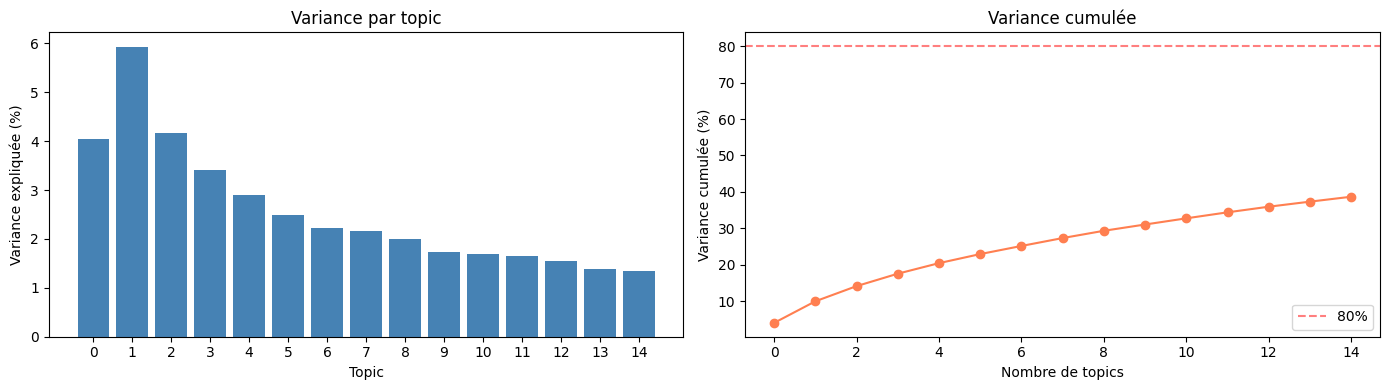

Variance totale expliquée : 38.7%


In [17]:
# Variance expliquée
variance = svd.explained_variance_ratio_
cumulative = np.cumsum(variance)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.bar(range(N_TOPICS), variance * 100, color='steelblue')
ax1.set_xlabel('Topic')
ax1.set_ylabel('Variance expliquée (%)')
ax1.set_title('Variance par topic')
ax1.set_xticks(range(N_TOPICS))

ax2.plot(range(N_TOPICS), cumulative * 100, 'o-', color='coral')
ax2.axhline(y=80, color='red', linestyle='--', alpha=0.5, label='80%')
ax2.set_xlabel('Nombre de topics')
ax2.set_ylabel('Variance cumulée (%)')
ax2.set_title('Variance cumulée')
ax2.legend()

plt.tight_layout()
plt.show()
print(f'Variance totale expliquée : {cumulative[-1]*100:.1f}%')

In [18]:
# Topic dominant par produit
df['main_topic'] = topic_matrix.argmax(axis=1)

print('Distribution des topics dominants :')
print(df['main_topic'].value_counts().sort_index())

Distribution des topics dominants :
main_topic
0      74
1     148
2      35
3      40
4      22
5      29
6      54
7      24
8      16
9      12
10      3
11     13
12      3
13     20
14      7
Name: count, dtype: int64


In [19]:
# Top 10 mots par topic
feature_names = vectorizer.get_feature_names_out()

print('Top 10 mots par topic :\n')
for i in range(N_TOPICS):
    top_indices = svd.components_[i].argsort()[-10:][::-1]
    top_words = [feature_names[j] for j in top_indices]
    n_prod = (df['main_topic'] == i).sum()
    print(f'Topic {i:2d} ({n_prod:3d} produits) : {" | ".join(top_words)}')

Top 10 mots par topic :

Topic  0 ( 74 produits) : shirt | tap shoulder | tap | print | shoulder seam | ringspun | pvc free | pvc | ink | shoulder
Topic  1 (148 produits) : water | zipper | dwr | repellent | water repellent | durable water | dwr durable | sun | dry | weave
Topic  2 ( 35 produits) : odor | merino | control | natural odor | gladiodor | odor control | gladiodor natural | natural | capilene | control garment
Topic  3 ( 40 produits) : button | short | canvas | zip fly | fly | button closure | closure | welt | pant | jean
Topic  4 ( 22 produits) : merino | wool | merino wool | wash | wash cold | flat dry | cold lie | slow wash | resist odor | machine wash
Topic  5 ( 29 produits) : strap | mesh | shoulder strap | polyurethane | pad | compartment | polyurethane coating | coating | coating dwr | hold
Topic  6 ( 54 produits) : tencel | coverage | bra | blend | line | hip | jersey | neck | fleece | tank
Topic  7 ( 24 produits) : sun | sun protection | protection | upf | upf sun |

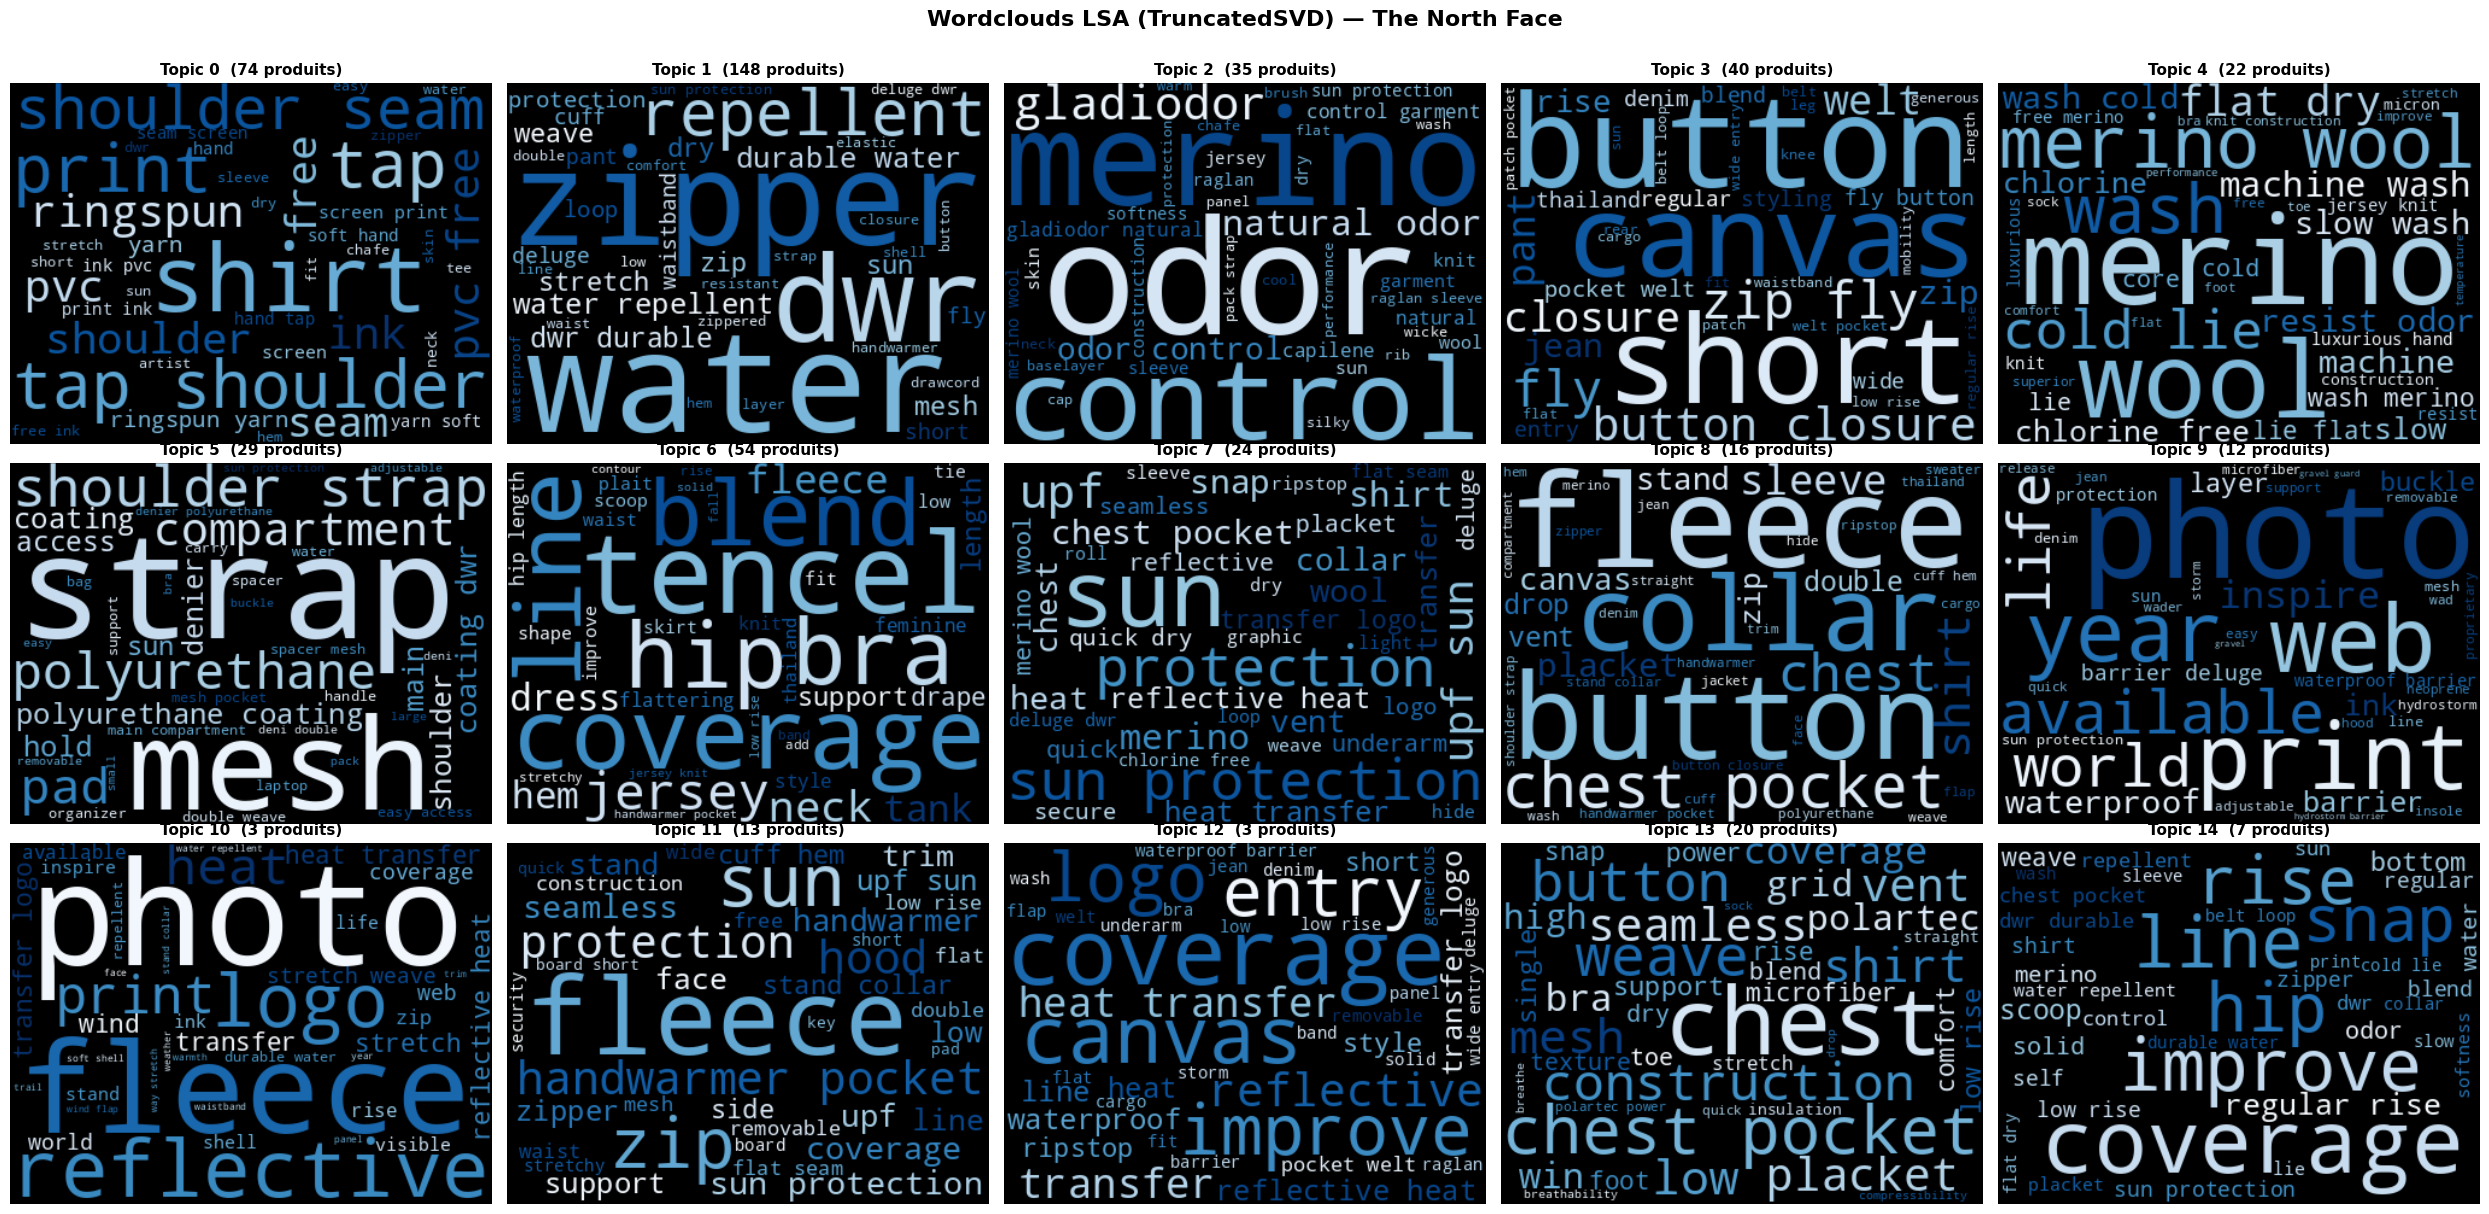

In [20]:
# Wordclouds par topic LSA
n_display_topics = N_TOPICS
n_cols = 5
n_rows = (n_display_topics + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, n_rows * 4))
axes = axes.flatten()

for i in range(n_display_topics):
    # Scores SVD directement → wordcloud plus précis que les textes bruts
    topic_scores = {
        feature_names[j]: max(0, svd.components_[i][j])
        for j in range(len(feature_names))
    }

    # Filtre : ne garder que les scores positifs non nuls
    topic_scores = {k: v for k, v in topic_scores.items() if v > 0}

    if not topic_scores:
        axes[i].set_visible(False)
        continue

    wc = WordCloud(
        width=400, height=300,
        background_color='black',
        colormap='Blues',
        max_words=40
    ).generate_from_frequencies(topic_scores)

    n_prod = (df['main_topic'] == i).sum()
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Topic {i}  ({n_prod} produits)', fontsize=11, fontweight='bold')
    axes[i].axis('off')

for j in range(n_display_topics, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Wordclouds LSA (TruncatedSVD) — The North Face', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [21]:
# Exemples de produits par topic dominant
print('Exemples de produits par topic dominant :\n')
for topic_id in range(min(6, N_TOPICS)):
    produits = df[df['main_topic'] == topic_id]['description'].str[:80].tolist()[:3]
    n = (df['main_topic'] == topic_id).sum()
    print(f'--- Topic {topic_id} ({n} produits) ---')
    for p in produits:
        print(f'  · {p}...')
    print()

Exemples de produits par topic dominant :

--- Topic 0 (74 produits) ---
  · City by the sea t-shirt - Illustrating the renaissance of sea-inspired, communit...
  · Dragoons t-shirt - These dragoons have dropped their weapons in favor of big wav...
  · Elias sweatshirt - The dirtbagger's complete wardrobe - wear it bouldering, work...

--- Topic 1 (148 produits) ---
  · Alpine guide pants - Skin in, climb ice, switch to rock, traverse a knife-edge r...
  · Alpine wind jkt - On high ridges, steep ice and anything alpine, this jacket ser...
  · Ascensionist jkt - Our most technical soft shell for full-on mountain pursuits s...

--- Topic 2 (35 produits) ---
  · Active classic boxers - There's a reason why our boxers are a cult favorite - th...
  · Cap 1 bottoms - Spring skiing is as transient as the wind. Move fast, move light...
  · Cap 1 boxer briefs - On bivy or belay, the form-fitting Capilene 1 Boxer Briefs ...

--- Topic 3 (40 produits) ---
  · Compound cargo pants - long - The ult

## Résumé & Conclusions

### Partie 1 — DBSCAN Clustering
- **Algorithme** : DBSCAN avec distance cosinus sur matrice TF-IDF
- **Décision clé** : `max_df=0.4` pour éliminer les mots génériques North Face ("common thread", "recycle"...) qui sinon créent un mega-cluster unique
- **Résultat** : clusters de produits aux descriptions vraiment similaires (vêtements techniques, équipement montagne, etc.)

### Partie 2 — Recommandation
- **Logique** : produits du même cluster DBSCAN = produits similaires
- **Fonction** : `find_similar_items(item_id)` retourne 5 recommandations
- **Application** : section "Vous pourriez aussi aimer" sur thenorthface.fr

### Partie 3 — LSA (TruncatedSVD)
- **Algorithme** : TruncatedSVD sur matrice TF-IDF → 15 topics latents
- **Différence avec DBSCAN** : un produit peut appartenir à plusieurs topics simultanément
- **Variable** : `topic_encoded_df` contient la représentation de chaque produit dans l'espace des topics
- **Intérêt business** : restructurer le catalogue en catégories plus adaptées à la navigation web